### Trying to grab true evidence using a wikipedia dump

In [2]:
import os
import json
import time
import random
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from sklearn.model_selection import train_test_split
from sentence_transformers import SentenceTransformer
from sklearn.metrics import accuracy_score, f1_score
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import requests
from functools import lru_cache

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [ ]:
df = pd.read_csv("combinedClaimDataset.csv")
print("Original dataset size:", len(df))
TARGET_SIZE = 12000
df_small = df.sample(n=TARGET_SIZE, random_state=42).reset_index(drop=True)
print("Downsampled size:", len(df_small))
df_small.head()

Original dataset size: 158744
Downsampled size: 12000


,claim,label,source
0,Budapest was the focal point of the American C...,refuted,fever
1,The Michelin Guide has given Tokyo by far the ...,supported,fever
2,The creators of Spider-Man gave the character ...,supported,fever
3,Says Michelle Obama waved red communist flags ...,refuted,liar
4,Steve Buscemi was in films in America.,supported,fever


In [ ]:
if df_small["label"].dtype == "object":
    label2id = {lbl: i for i, lbl in enumerate(sorted(df_small["label"].unique()))}
    id2label = {i: lbl for lbl, i in label2id.items()}
    df_small["label"] = df_small["label"].map(label2id)
else:
    num_labels = df_small["label"].nunique()
    id2label = {i: str(i) for i in range(num_labels)}
    label2id = {v: k for k, v in id2label.items()}

train_df, val_df = train_test_split(
    df_small,
    test_size=0.2,
    random_state=42,
    stratify=df_small["label"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("Train size:", len(train_df))
print("Val size:", len(val_df))


Train size: 9600
Val size: 2400


In [ ]:
WIKI_API = "https://en.wikipedia.org/w/api.php"

# Wikipedia Search
def wiki_search(query, limit=2):
    params = {
        "action": "query",
        "list": "search",
        "srsearch": query,
        "srlimit": limit,
        "format": "json"
    }
    r = requests.get(WIKI_API, params=params)
    if r.status_code != 200:
        return []
    data = r.json()
    return [item["title"] for item in data.get("query", {}).get("search", [])]

@lru_cache(maxsize=50000)
def wiki_intro(title):
    params = {
        "action": "query",
        "prop": "extracts",
        "exintro": True,
        "explaintext": True,
        "titles": title,
        "format": "json"
    }
    r = requests.get(WIKI_API, params=params)
    if r.status_code != 200:
        return ""
    pages = r.json().get("query", {}).get("pages", {})
    page = next(iter(pages.values()))
    return page.get("extract", "")

def retrieve_wikipedia_evidence(claim, k=2):
    titles = wiki_search(claim, limit=k)
    evidence_chunks = []

    for t in titles:
        text = wiki_intro(t)
        if text:
            sentences = text.split(". ")
            evidence_chunks.append(". ".join(sentences[:3]))

        time.sleep(0.1)

    return " ".join(evidence_chunks) if evidence_chunks else ""


print("Wikipedia retriever ready.")


Wikipedia retriever ready.


In [6]:
# tqdm.pandas()

# train_df["evidence_text"] = train_df["claim"].progress_apply(retrieve_wikipedia_evidence)
# val_df["evidence_text"]   = val_df["claim"].progress_apply(retrieve_wikipedia_evidence)
# train_df["evidence_text"] = train_df["evidence_text"].fillna("").astype(str)
# val_df["evidence_text"]   = val_df["evidence_text"].fillna("").astype(str)
# train_df.to_csv("train_with_wiki_evidence.csv", index=False)
# val_df.to_csv("val_with_wiki_evidence.csv", index=False)
# print("Saved train_with_wiki_evidence.csv and val_with_wiki_evidence.csv")


100%|██████████| 2400/2400 [05:08<00:00,  7.78it/s]

Saved train_with_wiki_evidence.csv and val_with_wiki_evidence.csv


In [28]:
model_name = "microsoft/deberta-v3-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize(batch):
    return tokenizer(
        batch["claim"],
        batch["evidence_text"],
        truncation=True,
        padding="max_length",
        max_length=384
    )

train_ds = Dataset.from_pandas(train_df)
val_ds   = Dataset.from_pandas(val_df)

train_ds = train_ds.map(tokenize, batched=True)
val_ds   = val_ds.map(tokenize, batched=True)

train_ds = train_ds.rename_column("label", "labels")
val_ds   = val_ds.rename_column("label", "labels")

train_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
val_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

num_labels = train_df["label"].nunique()
print("Dataset ready.")

Map: 100%|██████████| 2400/2400 [00:00<00:00, 10903.78 examples/s]

Dataset ready.


In [29]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
    use_safetensors=True
).to(device)

model = model.float()
model.gradient_checkpointing_enable()

print("Model loaded on:", device)

Loading weights: 100%|██████████| 198/198 [00:00<00:00, 14080.33it/s]
DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                       | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.dens

Model loaded on: cuda


In [30]:
batch_size = 12
training_args = TrainingArguments(
    output_dir="./deberta_rag_checkpoints",
    do_train=True,
    do_eval=True,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_steps=200,
    fp16=True,
    save_total_limit=1,
    save_only_model=True
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
    }
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
)
print("Trainer ready.")

Trainer ready.


In [31]:
trainer.train()
trainer.save_model("./final_deberta_rag_model")
print("Training complete.")

Step,Training Loss
200,0.916634
400,0.805698
600,0.789062
800,0.645931
1000,0.628753
1200,0.647430


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.52it/s]

Training complete.


In [ ]:
model.eval()
all_preds = []
all_labels = []

for i in range(len(val_ds)):
    batch = val_ds[i]
    input_ids = batch["input_ids"].unsqueeze(0).to(device)
    attention_mask = batch["attention_mask"].unsqueeze(0).to(device)
    labels = batch["labels"].item()

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=-1).item()

    all_preds.append(preds)
    all_labels.append(labels)

acc = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average="macro")

Accuracy: 0.67875
F1 Macro: 0.6376743790191971


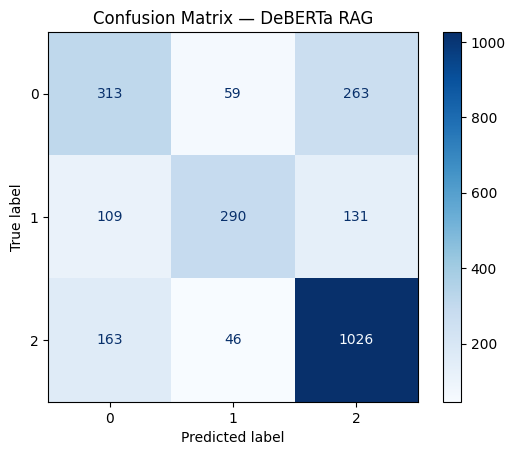

In [33]:
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix — DeBERTa RAG")
plt.show()

In [39]:
model.eval()
train_preds = []
train_labels = []

for i in range(len(train_ds)):
    batch = train_ds[i]

    input_ids = batch["input_ids"].unsqueeze(0).to(device)
    attention_mask = batch["attention_mask"].unsqueeze(0).to(device)
    label = batch["labels"].item()

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        pred = torch.argmax(outputs.logits, dim=-1).item()

    train_preds.append(pred)
    train_labels.append(label)

# Metrics
train_acc = accuracy_score(train_labels, train_preds)
train_f1 = f1_score(train_labels, train_preds, average="macro")

print("TRAIN Accuracy:", train_acc)
print("TRAIN F1 Macro:", train_f1)

TRAIN Accuracy: 0.8138541666666667
TRAIN F1 Macro: 0.7818685510188409


<Figure size 700x600 with 0 Axes>

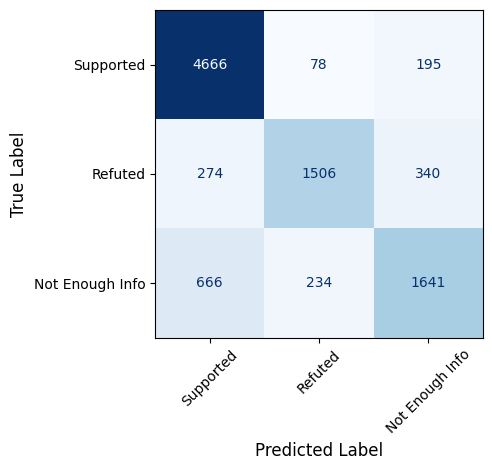

In [ ]:
display_labels = ["Supported", "Refuted", "Not Enough Info"]

cm = confusion_matrix(
    train_labels,
    train_preds,
    labels=[2, 1, 0]
)

plt.figure(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)

disp.plot(
    cmap="Blues",
    values_format="d",
    xticks_rotation=45,
    colorbar=False
)

plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)

plt.tight_layout()
plt.show()

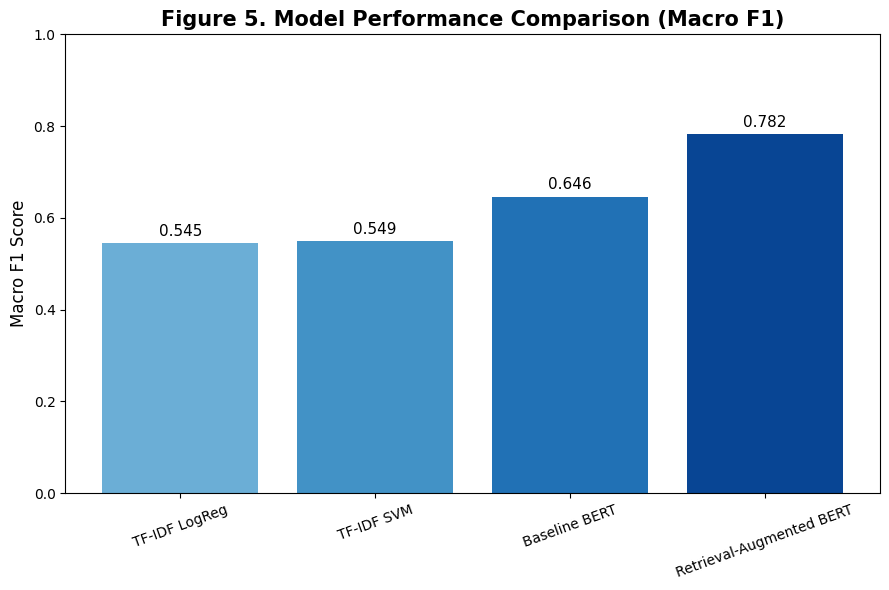

In [ ]:
models = [
    "TF-IDF LogReg",
    "TF-IDF SVM",
    "Baseline BERT",
    "Retrieval-Augmented BERT"
]

# Hard coded from other files since switching from gpu enabled desktop to laptop
f1_scores = [
    0.5447,   # LogReg
    0.5488,   # SVM
    0.6463,   # Baseline BERT
    0.7819    # Retrieval-Augmented BERT
]

plt.figure(figsize=(9, 6))

bars = plt.bar(models, f1_scores, color=["#6baed6", "#4292c6", "#2171b5", "#084594"])

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.ylim(0, 1.0)
plt.ylabel("Macro F1 Score", fontsize=12)

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [ ]:
table2 = pd.DataFrame({
    "Model": [
        "TF-IDF Logistic Regression",
        "TF-IDF SVM",
        "Baseline BERT",
        "Retrieval-Augmented BERT"
    ],
    "Test Macro F1": [
        0.5447,
        0.5488,
        0.6463,
        0.7819
    ]
})

table2

,Model,Test Macro F1
0,TF-IDF Logistic Regression,0.5447
1,TF-IDF SVM,0.5488
2,Baseline BERT,0.6463
3,Retrieval-Augmented BERT,0.7819
